In [1]:
%matplotlib inline
import numpy as np
import torch

torch.set_printoptions(edgeitems=2)

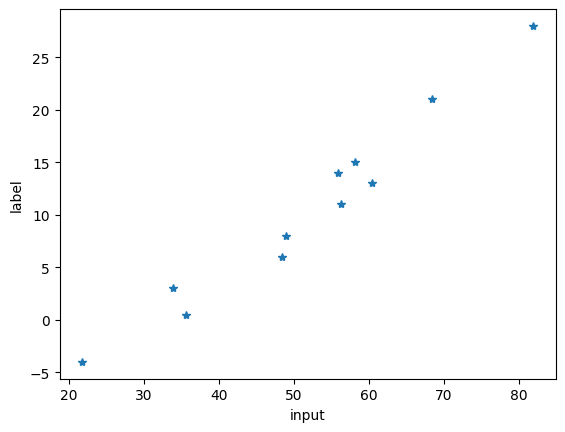

In [2]:
t_u = [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4]  # 输入
t_c = [0.5, 14.0, 15.0, 28.0, 11.0, 8.0, 3.0, -4.0, 6.0, 13.0, 21.0]  # 标签值

t_u = torch.tensor(t_u)
t_un = 0.1 * t_u  # 输入
t_c = torch.tensor(t_c)

from matplotlib import pyplot as plt

plt.plot(t_u.numpy(), t_c.numpy(), "*")
plt.xlabel("input")
plt.ylabel("label")
plt.show()

In [3]:
def model(t_u, w, b):
    return w * t_u + b


w = torch.ones(())
b = torch.zeros(())

print("w:", w)
print("w:", w.shape)
print("b:", b)
print("b:", b.shape)

t_p = model(t_u, w, b)
print("t_p:", t_p)
print("t_p:", t_p.shape)

w: tensor(1.)
w: torch.Size([])
b: tensor(0.)
b: torch.Size([])
t_p: tensor([35.7000, 55.9000, 58.2000, 81.9000, 56.3000, 48.9000, 33.9000, 21.8000,
        48.4000, 60.4000, 68.4000])
t_p: torch.Size([11])


In [4]:
def loss_fn(t_p, t_c):
    squared_diffs = (t_p - t_c) ** 2
    return squared_diffs.mean()


loss = loss_fn(t_p, t_c)
print("loss:", loss)
print("loss:", loss.shape)

loss: tensor(1763.8848)
loss: torch.Size([])


In [5]:
# requires_grad=True
params = torch.tensor([1.0, 2.0], requires_grad=True)
params

tensor([1., 2.], requires_grad=True)

In [6]:
w, b = params
print("w:", w)
print("b:", b)

w: tensor(1., grad_fn=<UnbindBackward0>)
b: tensor(2., grad_fn=<UnbindBackward0>)


In [7]:
params.grad is None

True

In [8]:
loss = loss_fn(model(t_u, *params), t_c)
print("loss:", loss)
print("params:", params)
print("params.grad:", params.grad)

# 当我们计算损失时, 参数 w 和 b 需要计算梯度.
# 除了执行实际的计算外, PyTorch 还创建了以操作为节点的自动求导图.
# 当我们调用 loss.backward() 时, PyTorch 将反向遍历此图以计算梯度.
loss.backward()

params.grad

loss: tensor(1933.0845, grad_fn=<MeanBackward0>)
params: tensor([1., 2.], requires_grad=True)
params.grad: None


tensor([4724.4966,   86.6000])

In [9]:
# 我们可以有任意数量的 requires_grad 为 True 的张量和任意组合的函数.
# 在这种情况下, PyTorch 将计算整个函数链(计算图)中损失的导数, 并将它们的值"累加"到这些张量的 grad 属性中(图的叶节点).
# 注意, 这是许多 PyTorch 初学者以及一些有经验的人经常会弄错的, 我们在这里要强调的是导数是"累加"存储到 grad 属性中的.
# 让我们一起复述一遍: 调用 backward() 将导致导数在叶节点上累加, 因此如果调用 backward(), 则会计算损失,
# 再次调用 backward()(就像在任何训练循环中一样), 每个叶节点上的梯度将在上一次迭代中计算的梯度之上累加(求和), 这会导致梯度计算不正确.
# 为了防止这种情况发生, 我们需要在每次迭代时明确地将梯度归零. 我们可以就地使用 zero()_ 方法轻松地完成这一任务

print("params:", params)  # 参数没有被更新
print("params.grad:", params.grad)  # 梯度已经存在, 第一次的梯度

loss = loss_fn(
    model(t_u, *params), t_c
)  # 再次执行正向传播, 得到的损失应该是一样的, 但由于梯度是累加的, 所以梯度不一样
print("loss:", loss)
print("params.grad:", params.grad)  # 第一次的梯度

loss.backward()

params.grad  # 第二次的梯度

params: tensor([1., 2.], requires_grad=True)
params.grad: tensor([4724.4966,   86.6000])
loss: tensor(1933.0845, grad_fn=<MeanBackward0>)
params.grad: tensor([4724.4966,   86.6000])


tensor([9448.9932,  173.2000])

In [10]:
# 我们可以有任意数量的 requires_grad 为 True 的张量和任意组合的函数.
# 在这种情况下, PyTorch 将计算整个函数链(计算图)中损失的导数, 并将它们的值"累加"到这些张量的 grad 属性中(图的叶节点).
# 注意, 这是许多 PyTorch 初学者以及一些有经验的人经常会弄错的, 我们在这里要强调的是导数是"累加"存储到 grad 属性中的.
# 让我们一起复述一遍: 调用 backward() 将导致导数在叶节点上累加, 因此如果调用 backward(), 则会计算损失,
# 再次调用 backward()(就像在任何训练循环中一样), 每个叶节点上的梯度将在上一次迭代中计算的梯度之上累加(求和), 这会导致梯度计算不正确.
# 为了防止这种情况发生, 我们需要在每次迭代时明确地将梯度归零. 我们可以就地使用 zero()_ 方法轻松地完成这一任务

print("params:", params)  # 参数没有被更新
print("params.grad:", params.grad)  # 梯度已经存在, 第二次的梯度

loss = loss_fn(
    model(t_u, *params), t_c
)  # 再次执行正向传播, 得到的损失应该是一样的, 但由于梯度是累加的, 所以梯度不一样
print("loss:", loss)
print("params.grad:", params.grad)  # 第二次的梯度

if params.grad is not None:
    params.grad.zero_()  # 将梯度归零

loss.backward()

params.grad  # 和第一次的梯度一样

params: tensor([1., 2.], requires_grad=True)
params.grad: tensor([9448.9932,  173.2000])
loss: tensor(1933.0845, grad_fn=<MeanBackward0>)
params.grad: tensor([9448.9932,  173.2000])


tensor([4724.4966,   86.6000])

In [11]:
def training_loop(n_epochs, learning_rate, params, t_u, t_c):
    for epoch in range(1, n_epochs + 1):
        # 将梯度归零
        if params.grad is not None:
            params.grad.zero_()

        t_p = model(t_u, *params)
        loss = loss_fn(t_p, t_c)
        loss.backward()  # 调用 loss.backward() 时, PyTorch 将反向遍历此图以计算梯度

        # PyTorch 允许我们在不需要的时候关闭自动求导, 使用上下文管理器 torch.no_grad().
        with torch.no_grad():
            params -= learning_rate * params.grad  # 更新参数

        if epoch % 500 == 0:
            print("Epoch %d, Loss %f" % (epoch, float(loss)))

    return params

In [12]:
return_params = training_loop(
    n_epochs=5000,
    learning_rate=1e-2,
    params=torch.tensor([1.0, 0.0], requires_grad=True),
    t_u=t_un,
    t_c=t_c,
)

print("return_params:", return_params)
print("params:", params)

Epoch 500, Loss 7.860115
Epoch 1000, Loss 3.828538
Epoch 1500, Loss 3.092191
Epoch 2000, Loss 2.957698
Epoch 2500, Loss 2.933134
Epoch 3000, Loss 2.928648
Epoch 3500, Loss 2.927830
Epoch 4000, Loss 2.927679
Epoch 4500, Loss 2.927652
Epoch 5000, Loss 2.927647
return_params: tensor([  5.3671, -17.3012], requires_grad=True)
params: tensor([1., 2.], requires_grad=True)
